# FitNova form-error models: overfitting diagnostics

Learning curves, confusion matrices, and train/validation/test F1 for the three deployed form-error models and their plain supervised baselines. Each deployed model is a self-supervised (SSL) pretrain then fine-tune, multi-seed ensemble; each baseline is a no-SSL control that is not deployed. All numbers are read from the committed evaluation artifacts; figures are written to `docs/figures/summary_*.png`.

| Exercise | Model (deployed) | Errors |
|---|---|---|
| Squat | R(2+1)D-18, Motion-Disentangling SSL | Knees-inward (KIE), Knees-forward (KFE) |
| OHP (overhead press) | R(2+1)D-18, Motion-Disentangling SSL | Elbows, Knees |
| Shallow-Squat | ResNet-18, CVCSPC pose-contrastive SSL | squat depth |

In [1]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path.cwd().resolve()
while not (ROOT / "docs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from backend.training.aqa.eval.metrics import confusion_matrix_per_error, f1_per_error  # noqa: E402

FIG = ROOT / "docs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})
C_TRAIN, C_VAL, C_TEST = "#8C8C8C", "#4C72B0", "#C44E52"


def save(name):
    plt.tight_layout()
    p = FIG / f"summary_{name}.png"
    plt.savefig(p, bbox_inches="tight")
    print("saved", p.relative_to(ROOT))
    plt.show(); plt.close()


def load(rel):
    return pickle.loads((ROOT / rel).read_bytes())


SQUAT = load("backend/data/benchmark/squat/results.pkl")
OHP = load("backend/data/benchmark/ohp/results.pkl")
SHAL = load("backend/data/benchmark/shallow/results.pkl")
SQUAT_BL = load("docs/audit/data/squat_baseline_phase03_results.pkl")
OHP_BL = load("docs/audit/data/ohp_baseline_curve.pkl")
TVT = load("docs/audit/data/train_val_test_f1.pkl")

# Part A - Deployed models

## A1. Learning curves

Overfitting shows as the validation loss rising while training loss keeps falling past the best epoch. For all three deployed models the validation metric peaks and the run stops (dashed line = the saved `best.pt` epoch), so the deployed weights predate any degradation.

saved docs\figures\summary_deployed_learning_curves.png


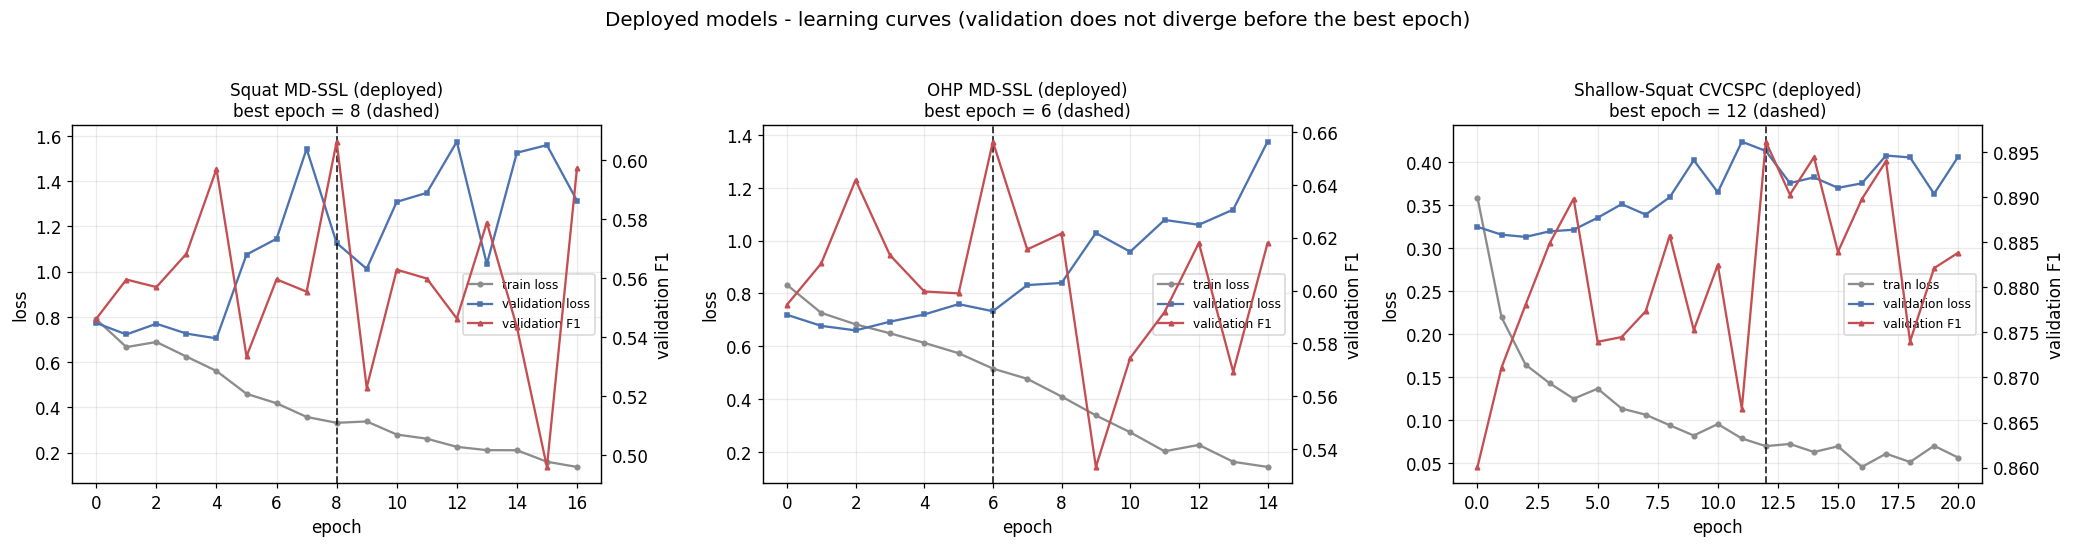

In [2]:
def learning_curve(ax, hist, val_key, title):
    ep = [h["epoch"] for h in hist]
    tr = [h["train_loss_mean"] for h in hist]
    vl = [h["val_loss_mean"] for h in hist]
    vf = [h[val_key] for h in hist]
    best = int(np.argmax(vf))
    ax.plot(ep, tr, color=C_TRAIN, marker="o", ms=3, label="train loss")
    ax.plot(ep, vl, color=C_VAL, marker="s", ms=3, label="validation loss")
    ax.axvline(ep[best], color="k", ls="--", lw=1.2, alpha=0.8)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    a2 = ax.twinx(); a2.grid(False)
    a2.plot(ep, vf, color=C_TEST, marker="^", ms=3, label="validation F1")
    a2.set_ylabel("validation F1")
    ax.set_title(f"{title}\nbest epoch = {ep[best]} (dashed)", fontsize=11)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")


fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
learning_curve(axes[0], SQUAT["finetune_curves"][42], "val_macro_f1", "Squat MD-SSL (deployed)")
learning_curve(axes[1], OHP["finetune_seeds"][42], "val_macro_f1", "OHP MD-SSL (deployed)")
learning_curve(axes[2], SHAL["finetune_seeds"][42], "val_f1", "Shallow-Squat CVCSPC (deployed)")
plt.suptitle("Deployed models - learning curves (validation does not diverge before the best epoch)", y=1.03, fontsize=13)
save("deployed_learning_curves")

## A2. Train vs validation vs test F1

Validation tracking test is the no-overfit signal: the score on the data used to tune the threshold matches the score on unseen test data. Train F1 above test is normal and only a concern when the gap is large, which here occurs only on the rarest class (Squat knees-inward).

saved docs\figures\summary_deployed_train_val_test.png


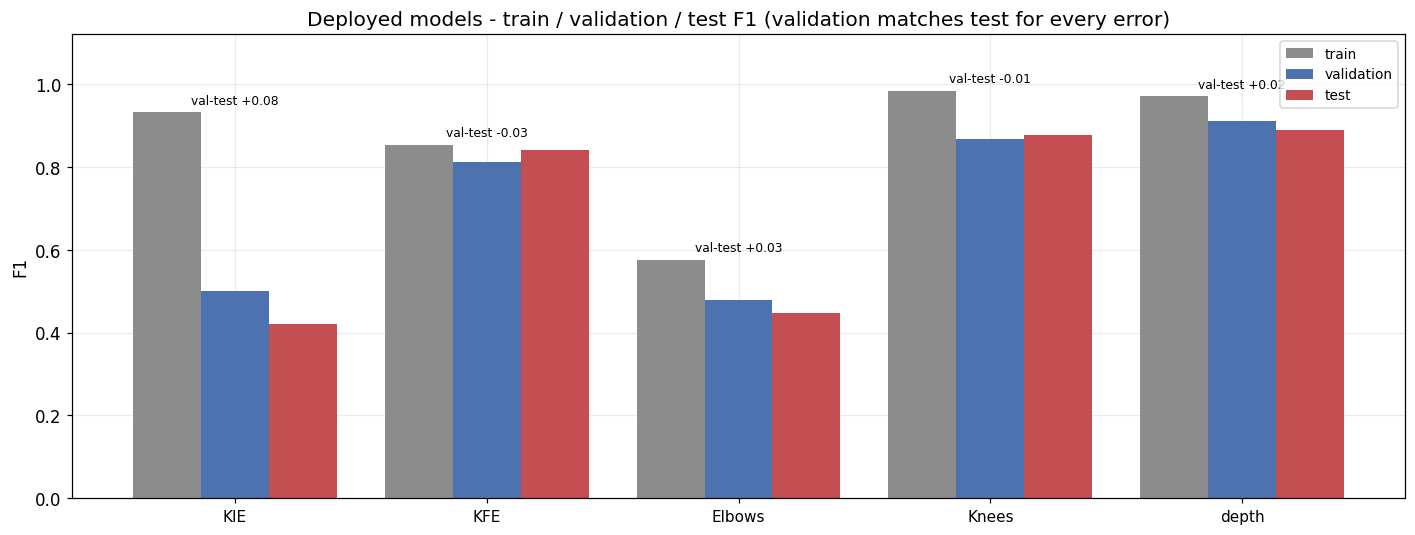

In [3]:
def tvt_bars(ax, keys, title, ylim=(0, 1.12)):
    labels = [k.split(" - ")[1] for k in keys]
    tr = [TVT[k]["train"] for k in keys]; vl = [TVT[k]["val"] for k in keys]; te = [TVT[k]["test"] for k in keys]
    x = np.arange(len(keys)); w = 0.27
    ax.bar(x - w, tr, w, color=C_TRAIN, label="train")
    ax.bar(x, vl, w, color=C_VAL, label="validation")
    ax.bar(x + w, te, w, color=C_TEST, label="test")
    for i in range(len(keys)):
        ax.text(i, max(tr[i], vl[i], te[i]) + 0.02, f"val-test {vl[i]-te[i]:+.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(*ylim); ax.set_ylabel("F1"); ax.set_title(title); ax.legend(loc="upper right", fontsize=9)


fig, ax = plt.subplots(figsize=(13, 5))
tvt_bars(ax, ["Squat MD-SSL - KIE", "Squat MD-SSL - KFE", "OHP MD-SSL - Elbows",
              "OHP MD-SSL - Knees", "Shallow CVCSPC - depth"],
         "Deployed models - train / validation / test F1 (validation matches test for every error)")
save("deployed_train_val_test")

## A3. Confusion matrices - validation vs test

A model that generalizes makes the same kind of mistakes on validation and on test. The two matrices per error are structurally similar (counts shown; layout `[[TN, FP], [FN, TP]]`).

saved docs\figures\summary_deployed_confusion.png


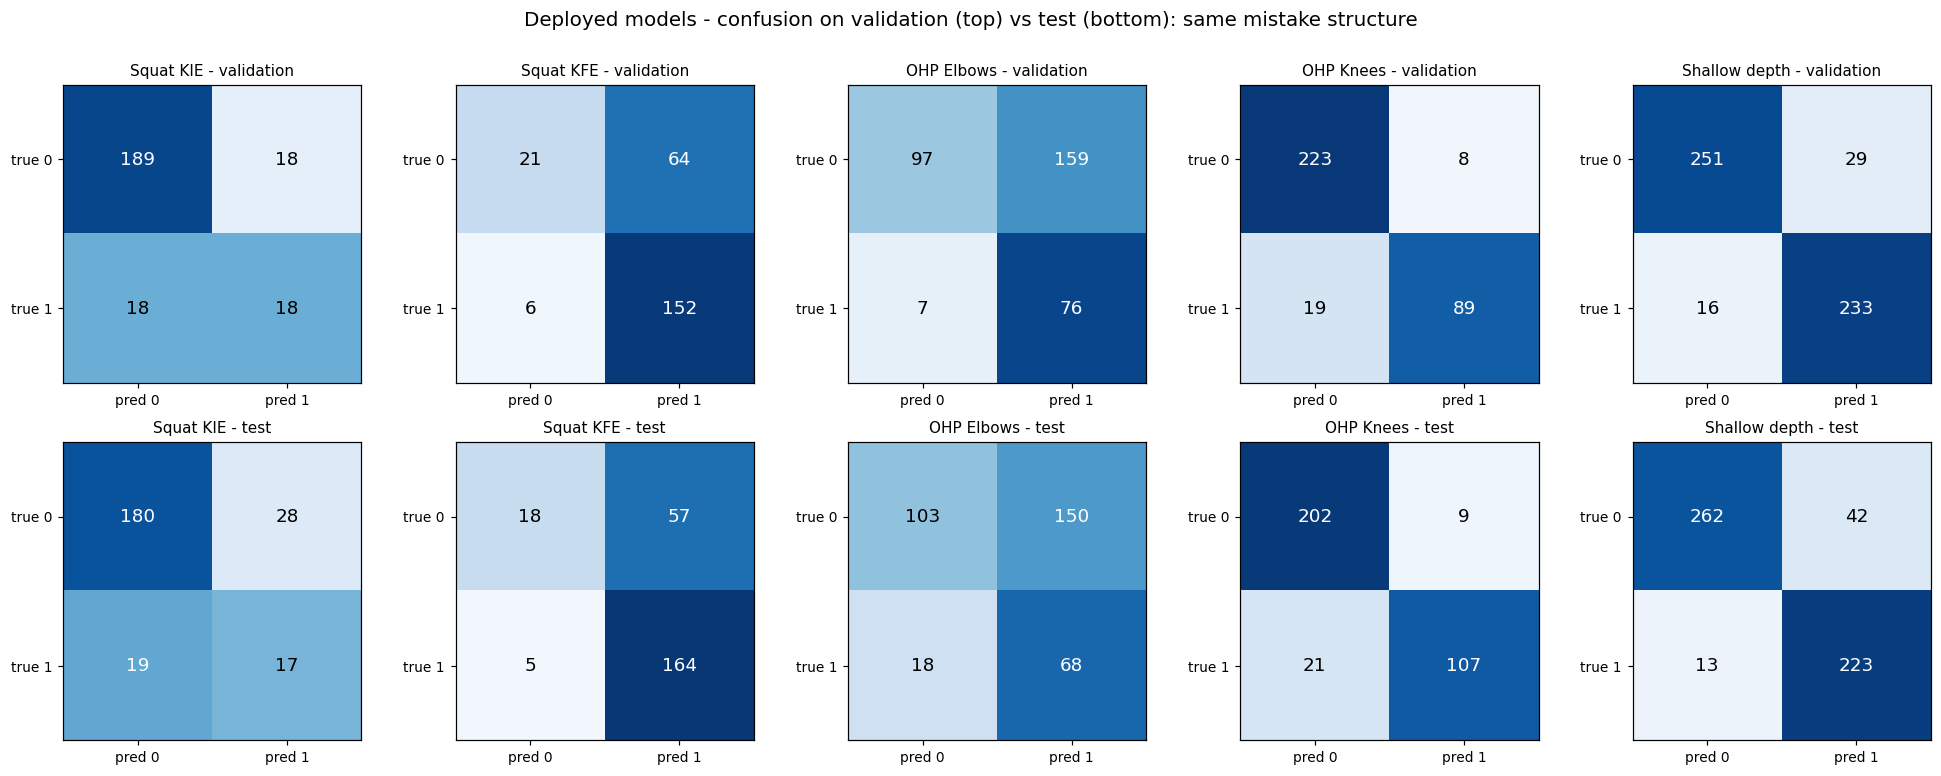

In [4]:
def conf(ax, lab, sc, thr, title):
    cm = confusion_matrix_per_error(np.asarray(lab), (np.asarray(sc) >= thr).astype(int))
    rn = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(rn, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if rn[i, j] > 0.5 else "black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"], fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(False)


sv, st = SQUAT["raw"]["ens_val_scores"], SQUAT["raw"]["ens_test_scores"]
svl, stl = SQUAT["raw"]["val_labels"], SQUAT["raw"]["test_labels"]
ov, ot = OHP["ensemble_val_scores"], OHP["ensemble_test_scores"]
ovl, otl = OHP["val_labels"], OHP["test_labels"]
errs = [("Squat KIE", svl[:, 0], sv[:, 0], stl[:, 0], st[:, 0], SQUAT["final"]["thresholds"]["KIE"]),
        ("Squat KFE", svl[:, 1], sv[:, 1], stl[:, 1], st[:, 1], SQUAT["final"]["thresholds"]["KFE"]),
        ("OHP Elbows", ovl[:, 0], ov[:, 0], otl[:, 0], ot[:, 0], OHP["thresholds"]["elbows"]),
        ("OHP Knees", ovl[:, 1], ov[:, 1], otl[:, 1], ot[:, 1], OHP["thresholds"]["knees"]),
        ("Shallow depth", SHAL["val_labels"], SHAL["ensemble_val_scores"],
         SHAL["test_labels"], SHAL["ensemble_test_scores"], SHAL["best_threshold"])]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for j, (name, vlab, vsc, tlab, tsc, thr) in enumerate(errs):
    conf(axes[0, j], vlab, vsc, thr, f"{name} - validation")
    conf(axes[1, j], tlab, tsc, thr, f"{name} - test")
plt.suptitle("Deployed models - confusion on validation (top) vs test (bottom): same mistake structure", y=1.0, fontsize=13)
save("deployed_confusion")

## A4. Validation-to-test F1 gap

The single deployment-overfitting number: how much F1 drops from validation (used to choose the operating threshold) to the untouched test set. Small bars = no overfit.

saved docs\figures\summary_deployed_val_test_gap.png


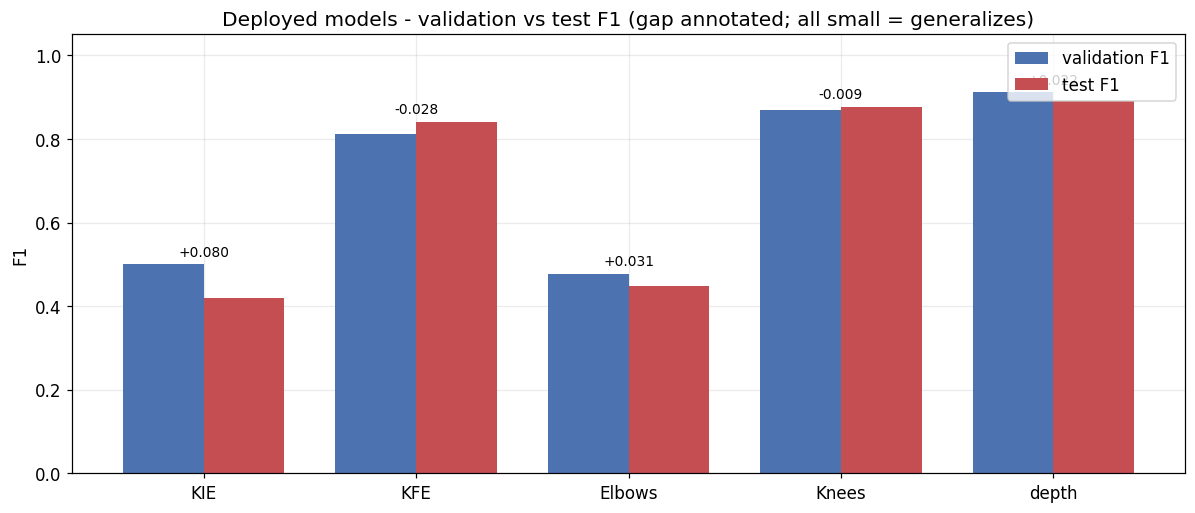

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.8))
keys = ["Squat MD-SSL - KIE", "Squat MD-SSL - KFE", "OHP MD-SSL - Elbows", "OHP MD-SSL - Knees", "Shallow CVCSPC - depth"]
labels = [k.split(" - ")[1] for k in keys]
vl = [TVT[k]["val"] for k in keys]; te = [TVT[k]["test"] for k in keys]
x = np.arange(len(keys)); w = 0.38
ax.bar(x - w / 2, vl, w, color=C_VAL, label="validation F1")
ax.bar(x + w / 2, te, w, color=C_TEST, label="test F1")
for i in range(len(keys)):
    ax.text(i, max(vl[i], te[i]) + 0.02, f"{vl[i]-te[i]:+.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05); ax.set_ylabel("F1")
ax.set_title("Deployed models - validation vs test F1 (gap annotated; all small = generalizes)")
ax.legend(loc="upper right")
save("deployed_val_test_gap")

# Part B - Baseline models (not deployed)

## B1. Learning curves

The plain supervised baselines (no SSL) push the validation loss up after the best epoch. The Squat baseline is the clearest (validation loss climbs sharply). Early stopping still saves the pre-divergence checkpoint, but these models overfit more than the deployed SSL ones.

saved docs\figures\summary_baseline_learning_curves.png


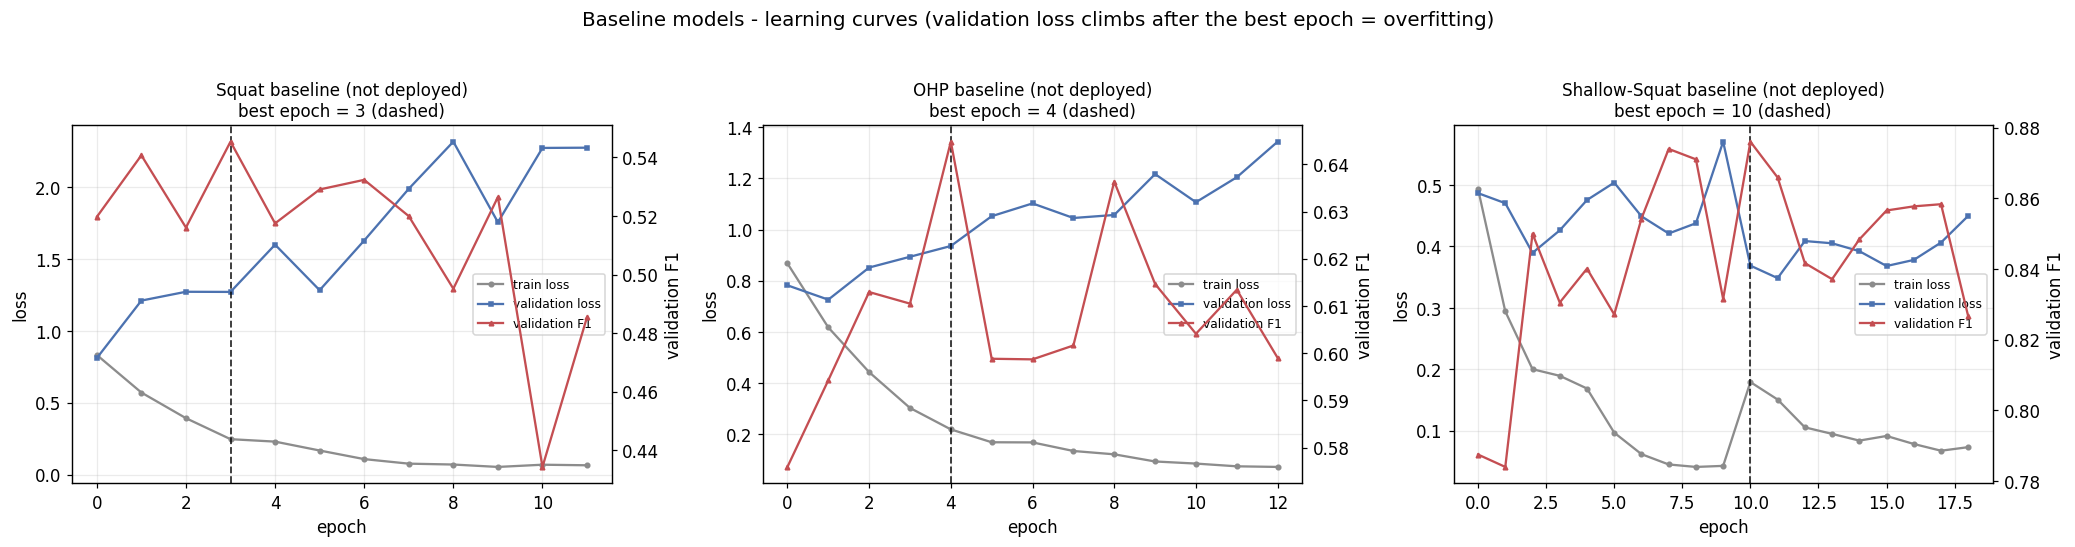

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
learning_curve(axes[0], SQUAT_BL["metrics_history"], "val_macro_f1", "Squat baseline (not deployed)")
learning_curve(axes[1], OHP_BL["metrics_history"], "val_macro_f1", "OHP baseline (not deployed)")
learning_curve(axes[2], SHAL["baseline_seeds"][42], "val_f1", "Shallow-Squat baseline (not deployed)")
plt.suptitle("Baseline models - learning curves (validation loss climbs after the best epoch = overfitting)", y=1.03, fontsize=13)
save("baseline_learning_curves")

## B2. Train vs validation vs test F1

The baselines fit the training data far better than test on the hard classes - the train bar towers over the test bar. The OHP baseline on Elbows is the starkest: train 0.94 vs test 0.42.

saved docs\figures\summary_baseline_train_val_test.png


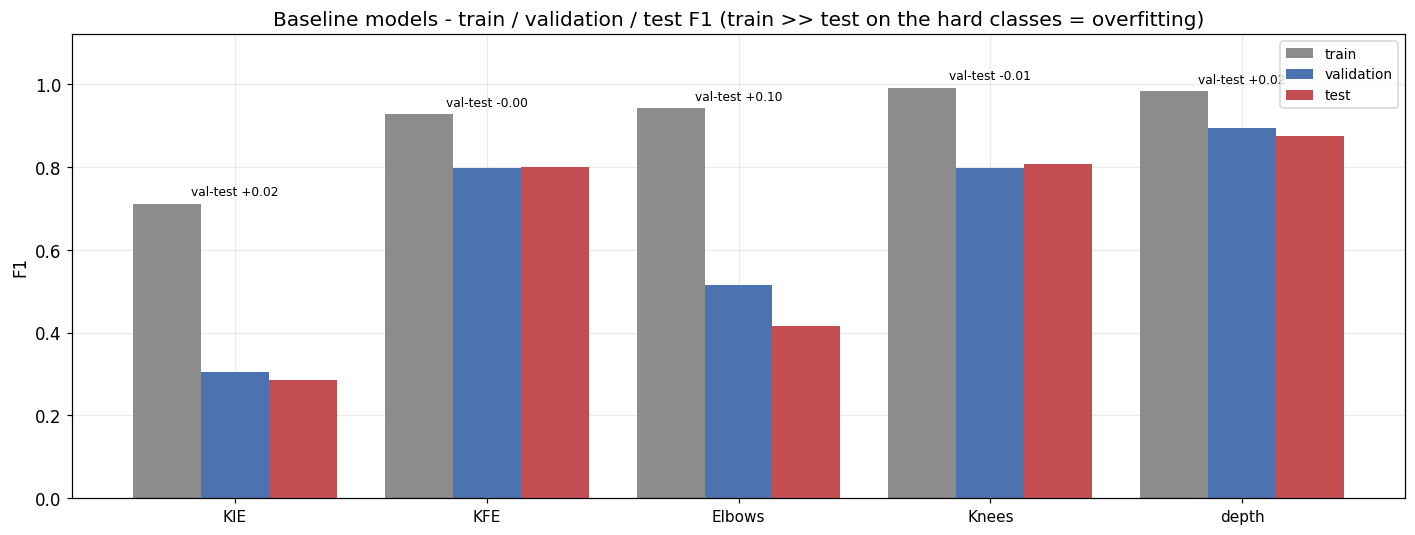

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
tvt_bars(ax, ["Squat baseline - KIE", "Squat baseline - KFE", "OHP baseline - Elbows",
              "OHP baseline - Knees", "Shallow baseline - depth"],
         "Baseline models - train / validation / test F1 (train >> test on the hard classes = overfitting)")
save("baseline_train_val_test")

## B3. SSL effect on the overfitting gaps

Baseline vs deployed SSL, side by side, for the overfitting gaps. SSL pretraining plus weight decay, head dropout, the multi-seed ensemble, and early stopping shrinks both the validation-to-test and train-to-test gaps, most dramatically on OHP Elbows.

saved docs\figures\summary_ssl_fix.png


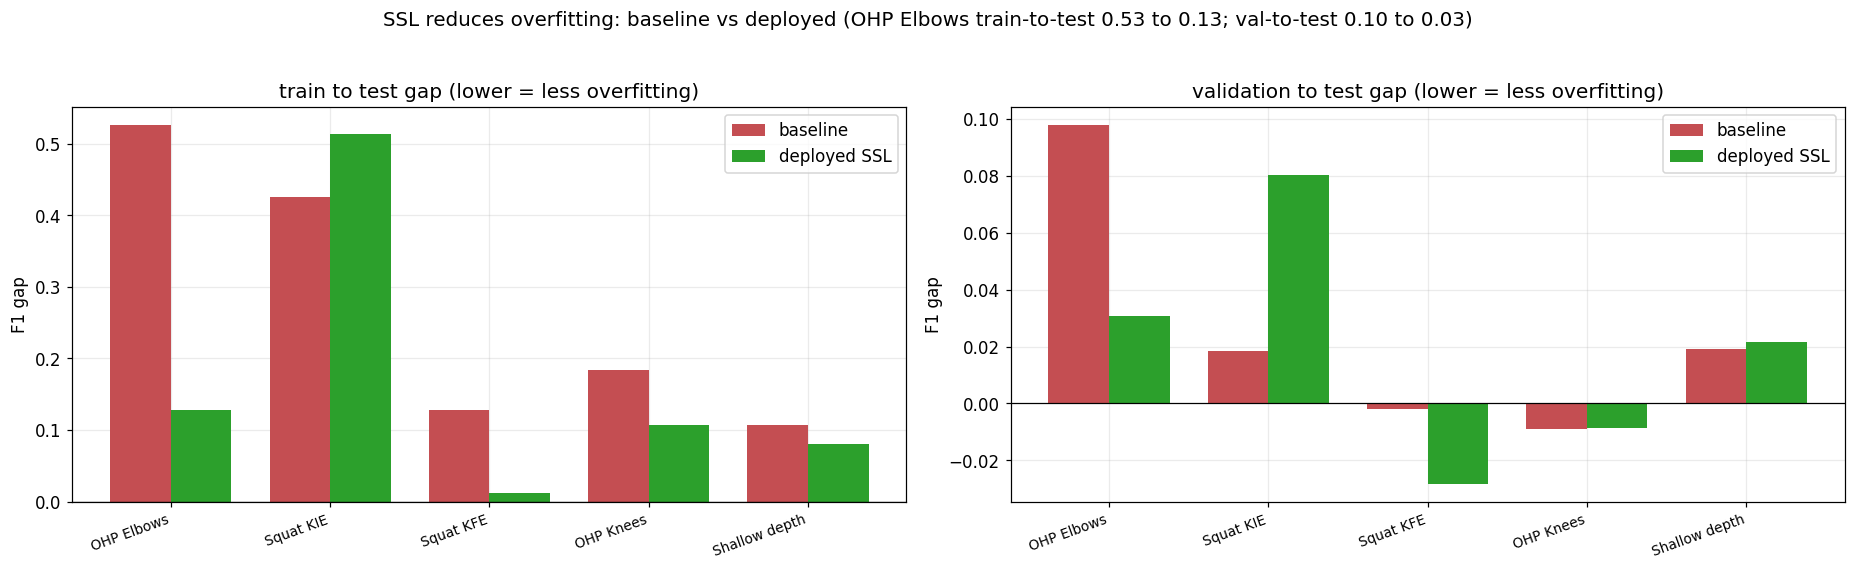

In [8]:
pairs = [("OHP Elbows", "OHP baseline - Elbows", "OHP MD-SSL - Elbows"),
         ("Squat KIE", "Squat baseline - KIE", "Squat MD-SSL - KIE"),
         ("Squat KFE", "Squat baseline - KFE", "Squat MD-SSL - KFE"),
         ("OHP Knees", "OHP baseline - Knees", "OHP MD-SSL - Knees"),
         ("Shallow depth", "Shallow baseline - depth", "Shallow CVCSPC - depth")]
names = [p[0] for p in pairs]
bl_tt = [TVT[p[1]]["train"] - TVT[p[1]]["test"] for p in pairs]
dp_tt = [TVT[p[2]]["train"] - TVT[p[2]]["test"] for p in pairs]
bl_vt = [TVT[p[1]]["val"] - TVT[p[1]]["test"] for p in pairs]
dp_vt = [TVT[p[2]]["val"] - TVT[p[2]]["test"] for p in pairs]
x = np.arange(len(pairs)); w = 0.38
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5))
a1.bar(x - w / 2, bl_tt, w, color="#C44E52", label="baseline")
a1.bar(x + w / 2, dp_tt, w, color="#2CA02C", label="deployed SSL")
a1.set_title("train to test gap (lower = less overfitting)")
a2.bar(x - w / 2, bl_vt, w, color="#C44E52", label="baseline")
a2.bar(x + w / 2, dp_vt, w, color="#2CA02C", label="deployed SSL")
a2.set_title("validation to test gap (lower = less overfitting)")
for ax_, bl, dp in [(a1, bl_tt, dp_tt), (a2, bl_vt, dp_vt)]:
    ax_.set_xticks(x); ax_.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax_.axhline(0, color="k", lw=0.8); ax_.set_ylabel("F1 gap"); ax_.legend()
plt.suptitle("SSL reduces overfitting: baseline vs deployed (OHP Elbows train-to-test 0.53 to 0.13; val-to-test 0.10 to 0.03)",
             y=1.03, fontsize=13)
save("ssl_fix")

# Summary

- **Deployed models: no validation-to-test overfitting.** Validation tracks test on every error (A2, A4), the learning curves stop before divergence (A1), and confusion is consistent across validation and test (A3).
- **Baselines: they overfit more.** Validation loss climbs after the best epoch (B1) and train F1 towers over test on the hard classes (B2).
- **SSL effect (B3):** pretraining + weight decay + dropout + ensemble + early stopping cut the overfitting gaps, e.g. OHP Elbows train-to-test 0.53 to 0.13 and validation-to-test 0.10 to 0.03.
- **Rare class:** Squat knees-inward keeps a large train-to-test gap even when deployed (train 0.93 vs test 0.42) from too few labelled examples, but its test F1 (0.42) equals the published state of the art and validation still tracks test, so the deployed model sits at the field's ceiling rather than being degraded.